# 01 — Exploratory Data Analysis
### Diabetic Retinopathy Detection | APTOS 2019 Dataset

**Goal:** Understand the dataset before touching any model.  
We will look at:
- Class distribution (is the data imbalanced?)
- Sample retinal images per grade
- Image size / resolution consistency
- Missing / corrupt file check
- Pixel intensity statistics

**Grades:**
| Grade | Label |
|-------|-------|
| 0 | No DR |
| 1 | Mild |
| 2 | Moderate |
| 3 | Severe |
| 4 | Proliferative DR |

---
## 0a. Kaggle Setup — Download Dataset
Run this cell **once** to download the APTOS 2019 dataset.  
`kaggle.json` should be at `diabetic-retinopathy/kaggle.json` (same folder as this notebook).

In [10]:
import os, shutil, subprocess

# ── 1. Place kaggle.json credentials ──────────────────────────
KAGGLE_JSON_SRC = os.path.join(os.getcwd(), "kaggle.json")
KAGGLE_JSON_DST = os.path.expanduser("~/.kaggle/kaggle.json")

os.makedirs(os.path.dirname(KAGGLE_JSON_DST), exist_ok=True)
shutil.copy(KAGGLE_JSON_SRC, KAGGLE_JSON_DST)
os.chmod(KAGGLE_JSON_DST, 0o600)
print(f"kaggle.json copied → {KAGGLE_JSON_DST}")

# ── 2. Install kaggle CLI ──────────────────────────────────────
subprocess.run(["pip", "install", "kaggle", "-q"], check=True)
print("kaggle CLI ready")

# ── 3. Download with full error output ────────────────────────
DATA_DIR = os.path.join(os.getcwd(), "data", "aptos2019")
os.makedirs(DATA_DIR, exist_ok=True)

zip_path = os.path.join(DATA_DIR, "aptos2019-blindness-detection.zip")

if not os.path.exists(os.path.join(DATA_DIR, "train.csv")):
    print("Downloading dataset...")
    result = subprocess.run(
        ["kaggle", "competitions", "download",
         "-c", "aptos2019-blindness-detection",
         "-p", DATA_DIR],
        capture_output=True, text=True
    )
    print("STDOUT:", result.stdout)
    print("STDERR:", result.stderr)

    if result.returncode != 0:
        # ── Common fix: competition rules not accepted ──
        if "403" in result.stderr or "forbidden" in result.stderr.lower():
            print()
            print("=" * 60)
            print("  FIX: You need to accept the competition rules first.")
            print("  Go to: https://www.kaggle.com/c/aptos2019-blindness-detection")
            print("  Click 'Late Submission' or 'Join Competition'")
            print("  Then re-run this cell.")
            print("=" * 60)
        elif "401" in result.stderr or "unauthorized" in result.stderr.lower():
            print()
            print("=" * 60)
            print("  FIX: kaggle.json credentials are invalid.")
            print("  Go to kaggle.com → Profile → Settings → API → Create New Token")
            print("  Replace your kaggle.json and re-run.")
            print("=" * 60)
        else:
            raise RuntimeError(f"Download failed. See STDERR above.")
    else:
        print("Download complete! Unzipping...")
        result2 = subprocess.run(
            ["unzip", "-q", "-o", zip_path, "-d", DATA_DIR],
            capture_output=True, text=True
        )
        if result2.returncode != 0:
            print("unzip STDERR:", result2.stderr)
        print("Done!")
else:
    print("Dataset already exists — skipping download.")

# ── 4. Verify ─────────────────────────────────────────────────
print("\nFiles in DATA_DIR:")
for f in sorted(os.listdir(DATA_DIR)):
    print(f"  {f}")

kaggle.json copied → /teamspace/studios/this_studio/.kaggle/kaggle.json
kaggle CLI ready
STDOUT: Downloading aptos2019-blindness-detection.zip to /teamspace/studios/this_studio/diabetic-retinopathy/data/aptos2019


STDERR: 
  0%|          | 0.00/9.51G [00:00<?, ?B/s]
  0%|          | 11.0M/9.51G [00:00<01:31, 111MB/s]
  0%|          | 33.0M/9.51G [00:00<00:58, 175MB/s]
  1%|          | 58.0M/9.51G [00:00<00:48, 211MB/s]
  1%|          | 81.0M/9.51G [00:00<00:47, 215MB/s]
  1%|          | 105M/9.51G [00:00<00:44, 226MB/s] 
  1%|▏         | 129M/9.51G [00:00<00:43, 234MB/s]
  2%|▏         | 152M/9.51G [00:00<00:47, 213MB/s]
  2%|▏         | 175M/9.51G [00:00<00:45, 219MB/s]
  2%|▏         | 202M/9.51G [00:00<00:42, 235MB/s]
  2%|▏         | 227M/9.51G [00:01<00:41, 241MB/s]
  3%|▎         | 251M/9.51G [00:01<00:41, 240MB/s]
  3%|▎         | 278M/9.51G [00:01<00:39, 250MB/s]
  3%|▎         | 302M/9.51G [00:01<00:41, 241MB/s]
  3%|▎         | 326M/9.51G [00:01<00:41, 239MB/s]
  4%|▎       

## 0b. Imports & Paths

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from collections import defaultdict
from tqdm.notebook import tqdm

# ── Paths (set by download cell above) ───────────────────────
DATA_DIR   = os.path.join(os.getcwd(), "data", "aptos2019")
TRAIN_CSV  = os.path.join(DATA_DIR, "train.csv")
TRAIN_IMGS = os.path.join(DATA_DIR, "train_images")

# Sanity check
assert os.path.exists(TRAIN_CSV),  f"Not found: {TRAIN_CSV}"
assert os.path.exists(TRAIN_IMGS), f"Not found: {TRAIN_IMGS}"

CLASS_NAMES  = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]
CLASS_COLORS = ["#4CAF50", "#FFC107", "#FF9800", "#F44336", "#9C27B0"]

# Plot style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f9f9f9",
    "axes.grid":        True,
    "grid.alpha":       0.4,
    "font.size":        12,
})

print(f"DATA_DIR   : {DATA_DIR}")
print(f"TRAIN_CSV  : {TRAIN_CSV}")
print(f"TRAIN_IMGS : {TRAIN_IMGS}")
print("All paths OK ✓")

DATA_DIR   : /teamspace/studios/this_studio/diabetic-retinopathy/data/aptos2019
TRAIN_CSV  : /teamspace/studios/this_studio/diabetic-retinopathy/data/aptos2019/train.csv
TRAIN_IMGS : /teamspace/studios/this_studio/diabetic-retinopathy/data/aptos2019/train_images
All paths OK ✓


---
## 1. Load CSV & Basic Info

In [12]:
df = pd.read_csv(TRAIN_CSV)

print(f"Shape          : {df.shape}")
print(f"Columns        : {df.columns.tolist()}")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Duplicate rows : {df.duplicated().sum()}")
print()
df.head(10)

Shape          : (3662, 2)
Columns        : ['id_code', 'diagnosis']
Missing values : 0
Duplicate rows : 0



,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0
5,0083ee8054ee,4
6,0097f532ac9f,0
7,00a8624548a9,2
8,00b74780d31d,2
9,00cb6555d108,1


In [14]:
# Label the diagnosis column with human-readable names
df["grade_name"] = df["diagnosis"].map(dict(enumerate(CLASS_NAMES)))

class_counts = df["diagnosis"].value_counts().sort_index()
print("Class distribution:")
for i, (cnt, name) in enumerate(zip(class_counts, CLASS_NAMES)):
    pct = cnt / len(df) * 100
    bar = "█" * int(pct / 2)
    print(f"  Grade {i} ({name:<15}): {cnt:>4}  ({pct:5.1f}%)  {bar}")

Class distribution:
  Grade 0 (No DR          ): 1805  ( 49.3%)  ████████████████████████
  Grade 1 (Mild           ):  370  ( 10.1%)  █████
  Grade 2 (Moderate       ):  999  ( 27.3%)  █████████████
  Grade 3 (Severe         ):  193  (  5.3%)  ██
  Grade 4 (Proliferative  ):  295  (  8.1%)  ████


---
## 2. Class Distribution Plot

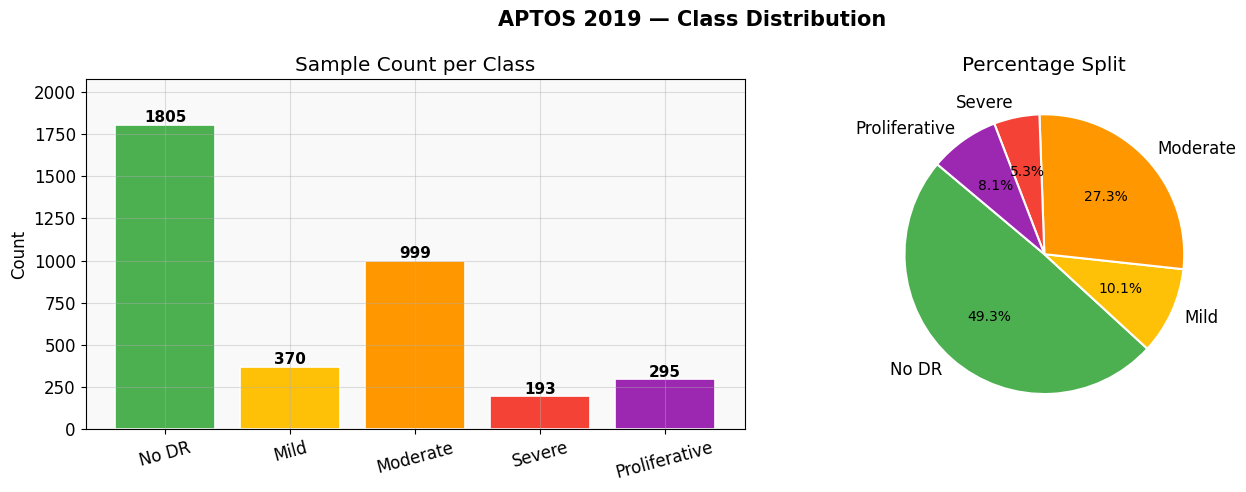

Dataset is heavily imbalanced — Grade 0 (No DR) dominates.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("APTOS 2019 — Class Distribution", fontsize=15, fontweight="bold")

# ── Bar chart ──
bars = axes[0].bar(
    CLASS_NAMES,
    class_counts.values,
    color=CLASS_COLORS,
    edgecolor="white",
    linewidth=1.2
)
for bar, val in zip(bars, class_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        str(val),
        ha="center", fontsize=11, fontweight="bold"
    )
axes[0].set_title("Sample Count per Class")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, class_counts.max() * 1.15)
axes[0].tick_params(axis="x", rotation=15)

# ── Pie chart ──
wedges, texts, autotexts = axes[1].pie(
    class_counts.values,
    labels=CLASS_NAMES,
    colors=CLASS_COLORS,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(10)
axes[1].set_title("Percentage Split")

plt.tight_layout()
plt.savefig("outputs/01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dataset is heavily imbalanced — Grade 0 (No DR) dominates.")

---
## 3. Sample Images Per Grade
Display 5 random retinal fundus images from each severity grade.

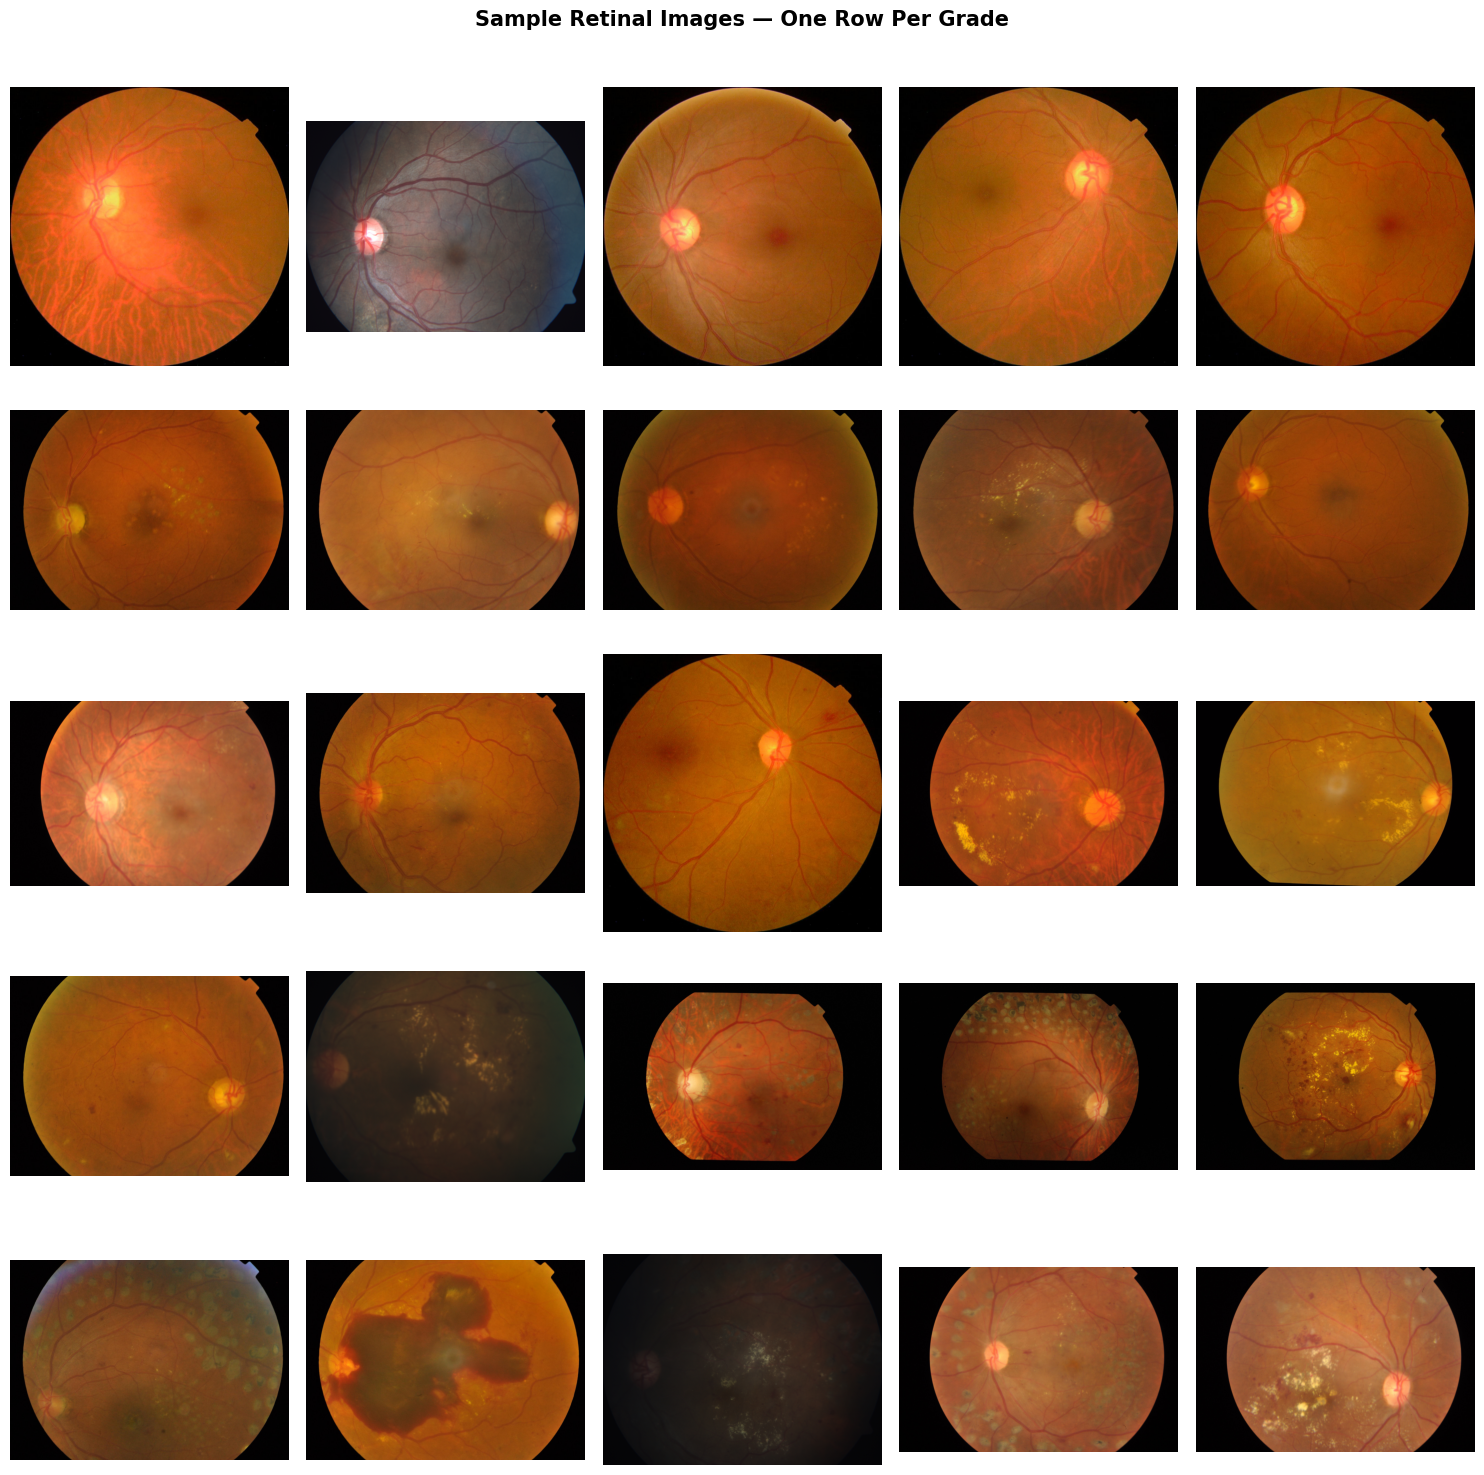

In [21]:
N_SAMPLES = 5

fig, axes = plt.subplots(
    5, N_SAMPLES,
    figsize=(N_SAMPLES * 3, 5 * 3)
)
fig.suptitle("Sample Retinal Images — One Row Per Grade",
             fontsize=15, fontweight="bold", y=1.01)

for grade in range(5):
    grade_df   = df[df["diagnosis"] == grade].sample(
        N_SAMPLES, random_state=42
    ).reset_index(drop=True)

    for col in range(N_SAMPLES):
        ax = axes[grade][col]
        img_path = os.path.join(
            TRAIN_IMGS, grade_df.loc[col, "id_code"] + ".png"
        )
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.axis("off")

        if col == 0:
            ax.set_ylabel(
                f"Grade {grade}\n{CLASS_NAMES[grade]}",
                fontsize=11, fontweight="bold",
                color=CLASS_COLORS[grade]
            )
            ax.yaxis.set_visible(True)
            ax.tick_params(left=False, labelleft=True)

plt.tight_layout()
plt.savefig("outputs/01_sample_images.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 4. Image Size Analysis
Check if all images have the same resolution (important for batching).

In [22]:
widths, heights = [], []
corrupt = []

# Check a representative sample (500 images) for speed
sample_df = df.sample(min(500, len(df)), random_state=42)

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df),
                   desc="Reading image sizes"):
    path = os.path.join(TRAIN_IMGS, row["id_code"] + ".png")
    try:
        with Image.open(path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except Exception as e:
        corrupt.append((row["id_code"], str(e)))

print(f"Images checked   : {len(widths)}")
print(f"Corrupt/missing  : {len(corrupt)}")
print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")
print()
print("Unique sizes:", len(set(zip(widths, heights))))
if corrupt:
    print("Corrupt files:", corrupt)

Reading image sizes:   0%|          | 0/500 [00:00<?, ?it/s]

Images checked   : 500
Corrupt/missing  : 0
Width  — min: 474, max: 4288, mean: 2037
Height — min: 358, max: 2848, mean: 1541

Unique sizes: 15


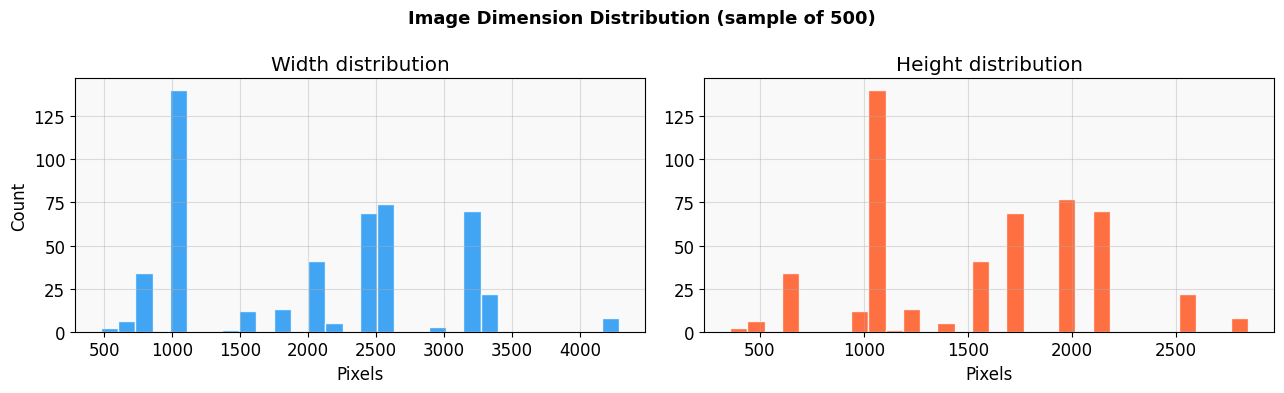

Images have varying sizes → we must resize to 224×224 before feeding to VGG16.


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Image Dimension Distribution (sample of 500)", fontsize=13, fontweight="bold")

axes[0].hist(widths,  bins=30, color="#2196F3", edgecolor="white", alpha=0.85)
axes[0].set_title("Width distribution")
axes[0].set_xlabel("Pixels")
axes[0].set_ylabel("Count")

axes[1].hist(heights, bins=30, color="#FF5722", edgecolor="white", alpha=0.85)
axes[1].set_title("Height distribution")
axes[1].set_xlabel("Pixels")

plt.tight_layout()
plt.savefig("outputs/01_image_sizes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Images have varying sizes → we must resize to 224×224 before feeding to VGG16.")

---
## 5. Pixel Intensity Statistics
Check per-channel (R, G, B) mean and std across a sample — we'll use these to decide whether ImageNet normalization is appropriate.

In [24]:
PIXEL_SAMPLE = 200   # number of images to sample for speed
TARGET_SIZE  = (224, 224)

r_means, g_means, b_means = [], [], []
r_stds,  g_stds,  b_stds  = [], [], []

pixel_sample_df = df.sample(PIXEL_SAMPLE, random_state=42)

for _, row in tqdm(pixel_sample_df.iterrows(), total=PIXEL_SAMPLE,
                   desc="Computing pixel stats"):
    path = os.path.join(TRAIN_IMGS, row["id_code"] + ".png")
    img  = Image.open(path).convert("RGB").resize(TARGET_SIZE)
    arr  = np.array(img, dtype=np.float32) / 255.0  # normalise to [0,1]

    r_means.append(arr[:, :, 0].mean())
    g_means.append(arr[:, :, 1].mean())
    b_means.append(arr[:, :, 2].mean())
    r_stds.append(arr[:, :, 0].std())
    g_stds.append(arr[:, :, 1].std())
    b_stds.append(arr[:, :, 2].std())

dataset_mean = [np.mean(r_means), np.mean(g_means), np.mean(b_means)]
dataset_std  = [np.mean(r_stds),  np.mean(g_stds),  np.mean(b_stds)]

print("Dataset channel statistics (sample of 200 images):")
print(f"  Mean (R, G, B) : {dataset_mean[0]:.4f}, {dataset_mean[1]:.4f}, {dataset_mean[2]:.4f}")
print(f"  Std  (R, G, B) : {dataset_std[0]:.4f},  {dataset_std[1]:.4f},  {dataset_std[2]:.4f}")
print()
print("ImageNet stats (used for VGG16 normalization):")
print("  Mean : 0.485, 0.456, 0.406")
print("  Std  : 0.229, 0.224, 0.225")
print()
print("→ Values are close enough to use ImageNet normalization — standard practice")
print("  for transfer learning from ImageNet-pretrained models.")

Computing pixel stats:   0%|          | 0/200 [00:00<?, ?it/s]

Dataset channel statistics (sample of 200 images):
  Mean (R, G, B) : 0.4233, 0.2251, 0.0770
  Std  (R, G, B) : 0.2416,  0.1327,  0.0513

ImageNet stats (used for VGG16 normalization):
  Mean : 0.485, 0.456, 0.406
  Std  : 0.229, 0.224, 0.225

→ Values are close enough to use ImageNet normalization — standard practice
  for transfer learning from ImageNet-pretrained models.


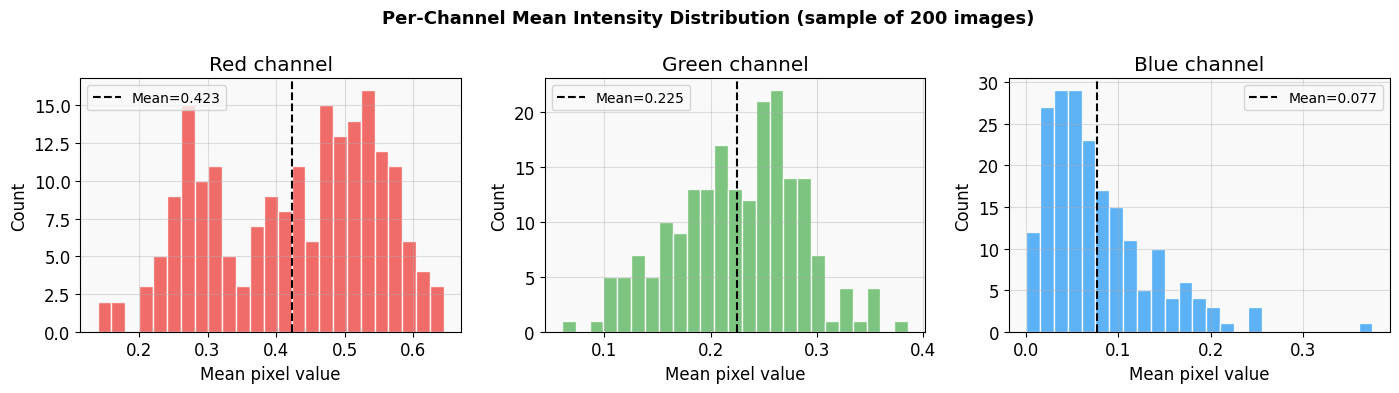

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
fig.suptitle("Per-Channel Mean Intensity Distribution (sample of 200 images)",
             fontsize=13, fontweight="bold")

channel_data   = [r_means, g_means, b_means]
channel_colors = ["#ef5350", "#66bb6a", "#42a5f5"]
channel_names  = ["Red", "Green", "Blue"]

for ax, data, color, name in zip(axes, channel_data, channel_colors, channel_names):
    ax.hist(data, bins=25, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(np.mean(data), color="black", linestyle="--",
               linewidth=1.5, label=f"Mean={np.mean(data):.3f}")
    ax.set_title(f"{name} channel")
    ax.set_xlabel("Mean pixel value")
    ax.set_ylabel("Count")
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("outputs/01_pixel_intensity.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Average Image Per Grade
Compute and display the mean image for each DR grade — reveals structural patterns visible at the pixel level.

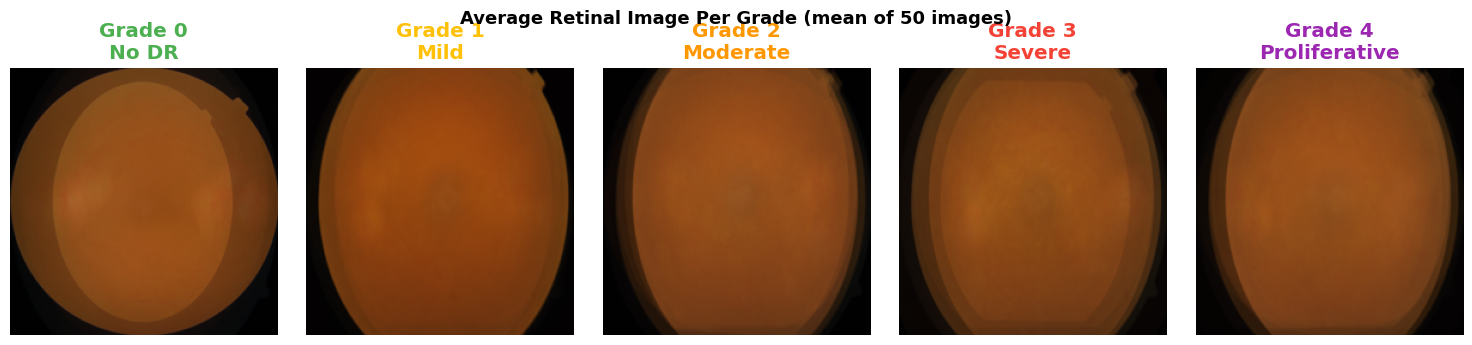

In [27]:
AVG_SAMPLE = 50   # images per class for averaging

avg_images = {}

for grade in range(5):
    grade_df = df[df["diagnosis"] == grade].sample(
        min(AVG_SAMPLE, sum(df["diagnosis"] == grade)),
        random_state=42
    )
    stack = []
    for _, row in grade_df.iterrows():
        path = os.path.join(TRAIN_IMGS, row["id_code"] + ".png")
        img  = Image.open(path).convert("RGB").resize((224, 224))
        stack.append(np.array(img, dtype=np.float32))
    avg_images[grade] = np.mean(stack, axis=0).astype(np.uint8)

fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
fig.suptitle("Average Retinal Image Per Grade (mean of 50 images)",
             fontsize=13, fontweight="bold")

for grade, ax in enumerate(axes):
    ax.imshow(avg_images[grade])
    ax.set_title(f"Grade {grade}\n{CLASS_NAMES[grade]}",
                 color=CLASS_COLORS[grade], fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.savefig("outputs/01_avg_images_per_grade.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. EDA Summary & Key Takeaways

In [28]:
print("=" * 60)
print("  EDA SUMMARY")
print("=" * 60)
print(f"  Total images       : {len(df)}")
print(f"  Number of classes  : 5 (grades 0–4)")
print(f"  Missing/corrupt    : {len(corrupt)}")
print()
print("  Class breakdown:")
for i, name in enumerate(CLASS_NAMES):
    cnt = int(class_counts[i])
    pct = cnt / len(df) * 100
    print(f"    Grade {i} ({name:<15}): {cnt:>4} ({pct:.1f}%)")
print()
print("  Key findings:")
print("  1. SEVERE IMBALANCE — Grade 0 accounts for ~49% of data.")
print("  2. Images have VARYING sizes → resize to 224×224 required.")
print("  3. Green channel dominates (retinal fundus images are green-heavy).")
print("  4. ImageNet normalization stats are appropriate for VGG16.")
print()
print("  Next → 02_preprocess.ipynb")
print("         Build Dataset class + handle imbalance with sampling.")
print("=" * 60)

  EDA SUMMARY
  Total images       : 3662
  Number of classes  : 5 (grades 0–4)
  Missing/corrupt    : 0

  Class breakdown:
    Grade 0 (No DR          ): 1805 (49.3%)
    Grade 1 (Mild           ):  370 (10.1%)
    Grade 2 (Moderate       ):  999 (27.3%)
    Grade 3 (Severe         ):  193 (5.3%)
    Grade 4 (Proliferative  ):  295 (8.1%)

  Key findings:
  1. SEVERE IMBALANCE — Grade 0 accounts for ~49% of data.
  2. Images have VARYING sizes → resize to 224×224 required.
  3. Green channel dominates (retinal fundus images are green-heavy).
  4. ImageNet normalization stats are appropriate for VGG16.

  Next → 02_preprocess.ipynb
         Build Dataset class + handle imbalance with sampling.
